In [3]:
from pathlib import Path
import pandas as pd

csv_path = Path("Forbes2000.csv")
if not csv_path.exists():
    csv_path = Path("PE06") / "Forbes2000.csv"

df = pd.read_csv(csv_path, encoding='ISO-8859-1', index_col=0)
df

,rank,name,country,category,sales,profits,assets,marketvalue
1,1,Citigroup,United States,Banking,94.71,17.85,1264.03,255.30
2,2,General Electric,United States,Conglomerates,134.19,15.59,626.93,328.54
3,3,American Intl Group,United States,Insurance,76.66,6.46,647.66,194.87
4,4,ExxonMobil,United States,Oil & gas operations,222.88,20.96,166.99,277.02
5,5,BP,United Kingdom,Oil & gas operations,232.57,10.27,177.57,173.54
...,...,...,...,...,...,...,...,...
1996,1996,Siam City Bank,Thailand,Banking,0.48,0.02,11.27,1.47
1997,1997,Yokogawa Electric,Japan,Business services & supplies,2.78,-0.22,2.96,3.29
1998,1998,Hindalco Industries,India,Materials,1.35,0.14,2.47,2.76
1999,1999,Nexans,France,Capital goods,5.09,0.00,2.71,0.88


In [6]:
report = df.describe(include='all').copy()
report.loc['Data Type'] = df.dtypes.astype(str)
report.loc['Missing Values'] = df.isna().sum()
report.loc['Present Values'] = df.notna().sum()

report

,rank,name,country,category,sales,profits,assets,marketvalue
count,2000.0,2000,2000,2000,2000.0,1995.0,2000.0,2000.0
unique,NaN,2000,61,27,NaN,NaN,NaN,NaN
top,NaN,Citigroup,United States,Banking,NaN,NaN,NaN,NaN
freq,NaN,1,751,313,NaN,NaN,NaN,NaN
mean,1000.5,NaN,NaN,NaN,9.69701,0.381133,34.04185,11.877655
std,577.494589,NaN,NaN,NaN,18.002592,1.765454,99.678786,24.460197
min,1.0,NaN,NaN,NaN,0.01,-25.83,0.27,0.02
25%,500.75,NaN,NaN,NaN,2.0175,0.08,4.025,2.72
50%,1000.5,NaN,NaN,NaN,4.365,0.2,9.345,5.15
75%,1500.25,NaN,NaN,NaN,9.5475,0.44,22.7925,10.6025


In [10]:
df = df.dropna()
report = df.describe(include='all').copy()
report.loc['Data Type'] = df.dtypes.astype(str)
report.loc['Missing Values'] = df.isna().sum()
report.loc['Present Values'] = df.notna().sum()

report

,rank,name,country,category,sales,profits,assets,marketvalue
count,1995.0,1995,1995,1995,1995.0,1995.0,1995.0,1995.0
unique,NaN,1995,61,27,NaN,NaN,NaN,NaN
top,NaN,Citigroup,United States,Banking,NaN,NaN,NaN,NaN
freq,NaN,1,748,313,NaN,NaN,NaN,NaN
mean,999.858647,NaN,NaN,NaN,9.709003,0.381133,34.06815,11.899183
std,577.752261,NaN,NaN,NaN,18.023506,1.765454,99.797418,24.486723
min,1.0,NaN,NaN,NaN,0.01,-25.83,0.27,0.02
25%,499.5,NaN,NaN,NaN,2.01,0.08,4.02,2.72
50%,999.0,NaN,NaN,NaN,4.36,0.2,9.33,5.15
75%,1500.5,NaN,NaN,NaN,9.575,0.44,22.745,10.62


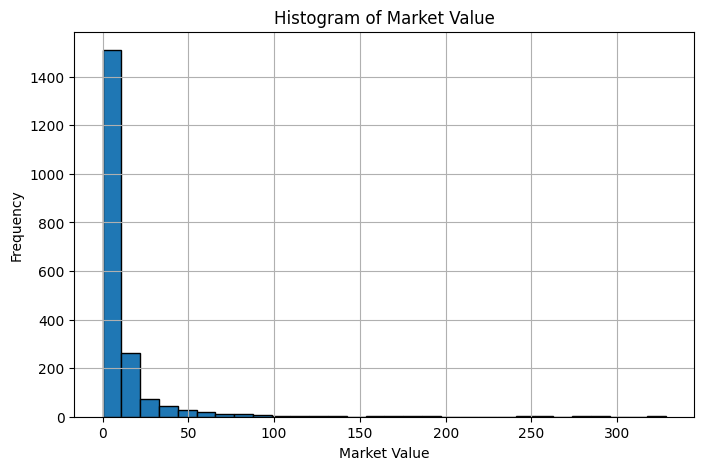

Skewness of marketvalue: 6.43
The marketvalue distribution is strongly right-skewed (positively skewed).


In [13]:
import matplotlib.pyplot as plt

marketvalue = df['marketvalue'].dropna()
ax = marketvalue.hist(bins=30, figsize=(8, 5), edgecolor='black')
ax.set_title('Histogram of Market Value')
ax.set_xlabel('Market Value')
ax.set_ylabel('Frequency')
plt.show()

skewness = marketvalue.skew()
if skewness > 1:
    description = 'strongly right-skewed (positively skewed)'
elif skewness > 0:
    description = 'slightly right-skewed (positively skewed)'
elif skewness < -1:
    description = 'strongly left-skewed (negatively skewed)'
elif skewness < 0:
    description = 'slightly left-skewed (negatively skewed)'
else:
    description = 'approximately symmetric'

print(f'Skewness of marketvalue: {skewness:.2f}')
print(f'The marketvalue distribution is {description}.')